In [1]:
import os
import numpy as np
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, TensorBoard
from glob import glob
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import datetime

# configuration and parameters

In [2]:
IMAGE_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 30
LEARNING_RATE = 1e-4

DATA_ROOT = r'C:\Users\pravin\Downloads\archive (6)\lol_dataset'

TRAIN_NORM = os.path.join(DATA_ROOT, 'our485', 'high')
TRAIN_LOW = os.path.join(DATA_ROOT, 'our485', 'low')
VAL_LOW = os.path.join(DATA_ROOT, 'eval15', 'low')
VAL_NORM = os.path.join(DATA_ROOT, 'eval15', 'high')
TEST_LOW = os.path.join(DATA_ROOT, 'eval15', 'low', '1.png')

print("TRAIN_NORM:", TRAIN_NORM)
print("TRAIN_LOW:", TRAIN_LOW)
print("VAL_LOW:", VAL_LOW)
print("VAL_NORM:", VAL_NORM)
print("TEST_LOW:", TEST_LOW)

for dirname, _, filenames in os.walk(DATA_ROOT):
    for filename in filenames[:5]:  
        print(os.path.join(dirname, filename))


TRAIN_NORM: C:\Users\pravin\Downloads\archive (6)\lol_dataset\our485\high
TRAIN_LOW: C:\Users\pravin\Downloads\archive (6)\lol_dataset\our485\low
VAL_LOW: C:\Users\pravin\Downloads\archive (6)\lol_dataset\eval15\low
VAL_NORM: C:\Users\pravin\Downloads\archive (6)\lol_dataset\eval15\high
TEST_LOW: C:\Users\pravin\Downloads\archive (6)\lol_dataset\eval15\low\1.png
C:\Users\pravin\Downloads\archive (6)\lol_dataset\eval15\high\1.png
C:\Users\pravin\Downloads\archive (6)\lol_dataset\eval15\high\111.png
C:\Users\pravin\Downloads\archive (6)\lol_dataset\eval15\high\146.png
C:\Users\pravin\Downloads\archive (6)\lol_dataset\eval15\high\179.png
C:\Users\pravin\Downloads\archive (6)\lol_dataset\eval15\high\22.png
C:\Users\pravin\Downloads\archive (6)\lol_dataset\eval15\low\1.png
C:\Users\pravin\Downloads\archive (6)\lol_dataset\eval15\low\111.png
C:\Users\pravin\Downloads\archive (6)\lol_dataset\eval15\low\146.png
C:\Users\pravin\Downloads\archive (6)\lol_dataset\eval15\low\179.png
C:\Users\pravi

# Data Pipeline and Augmentation

In [3]:
from glob import glob
import os

def pair_images(low_dir, norm_dir):
    if isinstance(low_dir, list):
        low_dir = low_dir[0]
    if isinstance(norm_dir, list):
        norm_dir = norm_dir[0]

    lows = sorted(glob(os.path.join(low_dir,'*.*')))
    norms = sorted(glob(os.path.join(norm_dir,'*.*')))
    norm_map = {os.path.basename(p): p for p in norms}
    paired_low, paired_norm = [], []

    for lp in lows:
        name = os.path.basename(lp)
        if name in norm_map:
            paired_low.append(lp)
            paired_norm.append(norm_map[name])

    print(f"Paired in [{os.path.basename(low_dir)}]:", len(paired_low))
    return paired_low, paired_norm


In [4]:
def load_image_pair(low_path, norm_path):
    low = tf.io.read_file(low_path)
    low = tf.image.decode_image(low, channels=3, expand_animations=False)
    low = tf.image.resize(low, (IMAGE_SIZE, IMAGE_SIZE))
    low = tf.image.convert_image_dtype(low, tf.float32)

    norm = tf.io.read_file(norm_path)
    norm = tf.image.decode_image(norm, channels=3, expand_animations=False)
    norm = tf.image.resize(norm, (IMAGE_SIZE, IMAGE_SIZE))
    norm = tf.image.convert_image_dtype(norm, tf.float32)

    return low, norm


In [5]:

def make_dataset(low_list, norm_list, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((low_list, norm_list))
    ds = ds.map(load_image_pair, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=1000)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_low, train_norm = pair_images(TRAIN_LOW, TRAIN_NORM)
val_low, val_norm = pair_images(VAL_LOW, VAL_NORM)

train_ds = make_dataset(train_low, train_norm )
val_ds = make_dataset(val_low, val_norm )

Paired in [low]: 485
Paired in [low]: 15


# Loss functions 

In [6]:


def color_constancy_loss(x):
    mean_rgb = tf.reduce_mean(x, axis=[1,2], keepdims=True)
    mr,mg,mb = mean_rgb[:,:,:,0],mean_rgb[:,:,:,1],mean_rgb[:,:,:,2]
    d_rg = tf.square(mr - mg)
    d_rb = tf.square(mr - mb)
    d_gb = tf.square(mb - mg)
    return tf.sqrt(tf.square(d_rg) + tf.square(d_rb) + tf.square(d_gb))

In [7]:
def exposure_loss(x, mean_val=0.8):
    x_mean = tf.reduce_mean(x, axis=3, keepdims=True)
    mean = tf.nn.avg_pool2d(x_mean, ksize=32, strides=32, padding='VALID')
    return tf.reduce_mean(tf.square(mean - mean_val))

In [8]:
def illumination_smoothness_loss(i_map):
    h_tv = tf.reduce_sum(tf.square(i_map[:,1:,:,:] - i_map[:,:-1,:,:]))
    w_tv = tf.reduce_sum(tf.square(i_map[:,:,1:,:] - i_map[:,:,:-1,:]))
    b = tf.cast(tf.shape(i_map)[0], tf.float32)
    h = tf.cast(tf.shape(i_map)[1], tf.float32)
    w = tf.cast(tf.shape(i_map)[2], tf.float32)
    loss = 2.0 * (h_tv / ((h-1)*w + 1e-8) + w_tv / (h*(w-1) + 1e-8)) / (b + 1e-8)
    return loss

In [9]:
import tensorflow as tf
from tensorflow import keras

class SpatialConsistencyColor(keras.losses.Loss):
    def __init__(self, pool_size=4, name="spatial_consistency_color"):
        super().__init__(name=name)
        self.pool_size = pool_size

       
        k_left = [[0, 0, 0],
                  [-1, 1, 0],
                  [0, 0, 0]]
        k_right = [[0, 0, 0],
                   [0, 1, -1],
                   [0, 0, 0]]
        k_up = [[0, -1, 0],
                [0, 1, 0],
                [0, 0, 0]]
        k_down = [[0, 0, 0],
                  [0, 1, 0],
                  [0, -1, 0]]

        kernels = tf.constant([k_left, k_right, k_up, k_down], dtype=tf.float32)
        kernels = tf.transpose(kernels, [1, 2, 0])[:, :, :, None]  
        self.kernels = tf.reshape(kernels, [3, 3, 1, 4])  

    def _mean_pool(self, x):
        return tf.nn.avg_pool2d(x, ksize=self.pool_size, strides=self.pool_size, padding='SAME')

    def _color_gradients(self, x):
      
        grads = []
        num_channels = x.shape[-1] or tf.shape(x)[-1]
        for c in range(num_channels):
            ch = x[..., c:c+1]
            grad = tf.nn.conv2d(ch, self.kernels, strides=1, padding='SAME') 
            grads.append(grad)
        return tf.concat(grads, axis=-1)

    def call(self, y_true, y_pred):
        
        ref = tf.nn.max_pool2d(y_true, ksize=self.pool_size, strides=self.pool_size, padding='SAME')
        out = self._mean_pool(y_pred)

        ref_grad = self._color_gradients(ref)
        out_grad = self._color_gradients(out)

        diff = tf.square(out_grad - ref_grad)
        return tf.reduce_mean(diff)


# Model 

In [10]:
def build_unlet():
    inp = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))

    # Encoder
    
    c1 = layers.Conv2D(64, 3, padding='same', activation='relu')(inp)
    p1 = layers.MaxPooling2D()(c1)
    c2 = layers.Conv2D(128, 3, padding='same', activation='relu')(p1)
    p2 = layers.MaxPooling2D()(c2)
    c3 = layers.Conv2D(256, 3, padding='same', activation='relu')(p2)
    p3 = layers.MaxPooling2D()(c3)

    # Bottleneck
    
    b = layers.Conv2D(512, 3, padding='same', activation='relu')(p3)

    # Decoder + illumination check
    
    u1 = layers.UpSampling2D()(b)
    u1 = layers.Concatenate()([u1, c3])
    c4 = layers.Conv2D(256, 3, padding='same', activation='relu')(u1)

    u2 = layers.UpSampling2D()(c4)
    u2 = layers.Concatenate()([u2, c2])
    c5 = layers.Conv2D(128, 3, padding='same', activation='relu')(u2)

    u3 = layers.UpSampling2D()(c5)
    u3 = layers.Concatenate()([u3, c1])
    c6 = layers.Conv2D(64, 3, padding='same', activation='relu')(u3)

    illum = layers.Conv2D(3, 1, padding='same', activation='sigmoid')(c6)
    enhanced = layers.Multiply()([inp, 1.0 + illum])


    return Model(inputs=inp, outputs=[enhanced, illum], name="UNLET_Model")

class UNLETModel(keras.Model):
    def __init__(self):
        super().__init__()
        self.unlet = build_unlet()
        self.spatial_loss = SpatialConsistencyColor()

    def compile(self, optimizer, **kwargs):
        super().compile(optimizer=optimizer, **kwargs)

    def train_step(self, data):
        low, norm = data
        with tf.GradientTape() as tape:
            enhanced, illum = self.unlet(low, training=True)

            # losses
            
            loss_l2 = tf.reduce_mean(tf.square(enhanced - norm))
            loss_color = tf.reduce_mean(color_constancy_loss(enhanced))
            loss_exposure = tf.reduce_mean(exposure_loss(enhanced))
            loss_illum = tf.reduce_mean(illumination_smoothness_loss(illum))
            loss_spatial = tf.reduce_mean(self.spatial_loss(low, enhanced))

            total = loss_l2 + 5.0*loss_color + 10.0*loss_exposure + 50.0*loss_illum + loss_spatial

        grads = tape.gradient(total, self.trainable_variables)
        
        grads = [g if g is not None else tf.zeros_like(v) for g, v in zip(grads, self.trainable_variables)]
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        return {
            "loss": total,
            "l2": loss_l2,
            "color": loss_color,
            "exposure": loss_exposure,
            "illum": loss_illum,
            "spatial": loss_spatial
        }

    def test_step(self, data):
        low, norm = data
        enhanced, illum = self.unlet(low, training=False)
        
        loss_l2 = tf.reduce_mean(tf.square(enhanced - norm))
        loss_color = tf.reduce_mean(color_constancy_loss(enhanced))
        loss_exposure = tf.reduce_mean(exposure_loss(enhanced))
        loss_illum = tf.reduce_mean(illumination_smoothness_loss(illum))
        loss_spatial = tf.reduce_mean(self.spatial_loss(low, enhanced))
    
        total = loss_l2 + 5.0*loss_color + 10.0*loss_exposure + 50*loss_illum + loss_spatial
        return {
            "loss": total,
            "l2": loss_l2,
            "color": loss_color,
            "exposure": loss_exposure,
            "illum": loss_illum,
            "spatial": loss_spatial
        }

# Training

In [11]:
model = UNLETModel()
model.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE))

logdir = os.path.join("logs", "UNLET", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
callbacks = [
    ModelCheckpoint("unlet_best.weights.h5", monitor="val_loss", save_best_only=True, save_weights_only=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, verbose=1),
    TensorBoard(log_dir=logdir),
]

model.build(input_shape=(None, 224, 224, 3))


model.fit(train_ds,
          epochs=EPOCHS,
          validation_data=val_ds,
          callbacks=callbacks)

Epoch 1/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 360s 6s/step - color: 22.8634 - exposure: 376.0352 - illum: 5.1900e-04 - l2: 14803.1162 - loss: 18706.8457 - spatial: 29.0351 - val_color: 37.5368 - val_exposure: 351.3437 - val_illum: 4.4493e-04 - val_l2: 12652.1084 - val_loss: 16384.3555 - val_spatial: 31.1020 - learning_rate: 1.0000e-04
Epoch 2/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 342s 6s/step - color: 11.2002 - exposure: 123.3855 - illum: 0.0057 - l2: 10274.7520 - loss: 11572.3916 - spatial: 7.4977 - val_color: 34.3763 - val_exposure: 328.0198 - val_illum: 0.0050 - val_l2: 14855.4541 - val_loss: 18319.8594 - val_spatial: 12.0789 - learning_rate: 1.0000e-04
Epoch 3/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 343s 6s/step - color: 69.9158 - exposure: 304.0262 - illum: 0.0098 - l2: 11197.8076 - loss: 14646.0332 - spatial: 57.8968 - val_color: 40.5980 - val_exposure: 247.0693 - val_illum: 0.0061 - val_l2: 11737.8838 - val_loss: 14427.9873 - val_spatial: 16.1161 - learning_rate: 1.0000e-04
Epoch 4/30
61/61 ━━━━━━━━━━━━━

# Inference & Visualization

In [12]:
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

IMAGE_SIZE = 256  

def enhance_unlet(model, image_path):
 
    img = Image.open(image_path).convert('RGB').resize((IMAGE_SIZE, IMAGE_SIZE))
    arr = np.array(img, dtype=np.float32) / 255.0
    arr = np.expand_dims(arr, 0)  # shape = (1, 256, 256, 3)

    enhanced, illum = model.unlet(arr, training=False)
    enh = (enhanced[0].numpy() * 255).clip(0, 255).astype(np.uint8)
    return Image.fromarray(enh)

def compare_plot_unlet(model, image_path):
    orig = Image.open(image_path).convert('RGB').resize((IMAGE_SIZE, IMAGE_SIZE))
    enhanced_img = enhance_unlet(model, image_path)
    auto = ImageOps.autocontrast(orig)

    fig, axs = plt.subplots(1, 3, figsize=(15, 6))
    axs[0].imshow(orig)
    axs[0].set_title("Original")
    axs[1].imshow(auto)
    axs[1].set_title("AutoContrast")
    axs[2].imshow(enhanced_img)
    axs[2].set_title("UNLET Enhanced")

    for ax in axs:
        ax.axis("off")
    plt.show()


# testing

Loaded best model weights for testing.
Found 1 test images.
Testing: 22.png


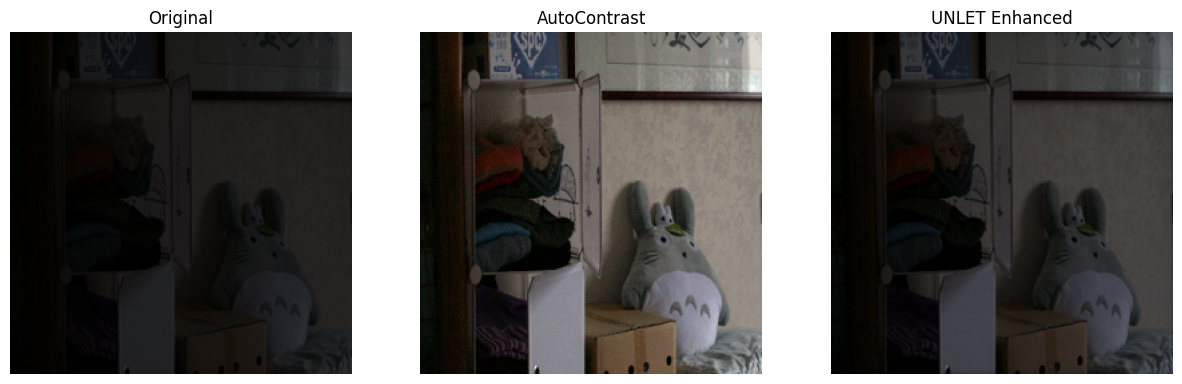

In [15]:
from glob import glob
import os

TEST_LOW = os.path.join(DATA_ROOT, 'eval15', 'low')
TEST_HIGH = os.path.join(DATA_ROOT, 'eval15', 'high') 

model.load_weights("unlet_best.weights.h5")

print("Loaded best model weights for testing.")

test_imgs = sorted(glob(os.path.join(TEST_LOW, r'C:\Users\pravin\Downloads\archive (6)\lol_dataset\eval15\low\22.png')))[:5]

print(f"Found {len(test_imgs)} test images.")

for p in test_imgs:
    print("Testing:", os.path.basename(p))
    compare_plot_unlet(model, p)
